In [ ]:
import urllib.request as req
import requests

from bs4 import BeautifulSoup
#선택자: select_one() : 하나의 값 ; select() : list 형태로 여러 개의 값을 반환
#tag : find()

In [ ]:
!pip install pandas
!pip install matplotlib

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

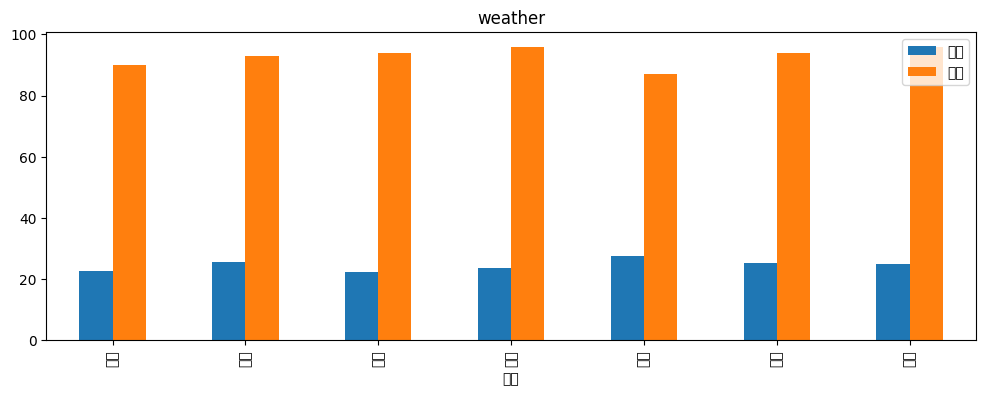

In [ ]:
import requests # Scraping
from bs4 import BeautifulSoup # Crawling
import pandas # Data analysis
import matplotlib as mpl
import matplotlib.pyplot as plt # Data visualization

#Scraping
url = "https://www.weather.go.kr/w/observation/land/city-obs.do"
source =requests.get(url)

#crawling
soup = BeautifulSoup(source.content, 'html.parser')
table = soup.find('table',{'class':'table-col'})

#save
data = []
for tr in table.find_all('tr'):
  ths = list(tr.find_all('th'))
  tds = list(tr.find_all('td'))
  for th in ths:
    if th.find("a") :
      point = th.find("a").string
      temp = tds[4].string
      humidity = tds[8].string
      data.append([point,temp,humidity])


data
with open ('weather.csv', 'w', encoding='utf-8') as f:
  f.write('지역,온도,습도\n',)
  for l in data:
    f.write(f"{l[0]},{l[1]},{l[2]}\n")

#전처리
df = pandas.read_csv('weather.csv', encoding='utf-8', index_col='지역')
df

city_df =  df.loc[['서울','부산','인천','대구','대전','광주','울산']]
city_df

#visualization
ax = city_df.plot(kind='bar',title='weather',figsize=(12,4))
plt.show() #window에서는 글꼴 설치 시 한글이 보임